# Qwen3-VL-8B-Instruct Demo

This notebook demonstrates how to use the Qwen3-VL-8B-Instruct model from Hugging Face for vision-language tasks.

## Installation

Install the required dependencies:

In [1]:
# !pip install git+https://github.com/huggingface/transformers
# !pip install accelerate torch pillow

## Import Libraries

In [1]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import torch

/home/sravani/miniconda3/envs/spatiallm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Model and Processor

In [2]:
# Load model with automatic device mapping
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct", 
    torch_dtype="auto", 
    device_map="auto"
)

# Load processor
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

Loading weights: 100%|██████████| 750/750 [00:12<00:00, 58.83it/s, Materializing param=model.visual.pos_embed.weight]                                 


## Example 1: Image Description from URL

In [3]:
# Prepare messages with image URL
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

# Process input
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

# Generate response
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

# Decode output
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("Model Response:")
print(output_text[0])

Model Response:
This is a heartwarming and serene photograph capturing a moment of connection between a woman and her dog on a beach at sunset.

**Key Elements:**

*   **The Subjects:** A woman and a large, light-brown Labrador Retriever are the central focus. The dog is sitting upright on the sand, wearing a colorful patterned harness and a red leash. The woman is sitting cross-legged in the sand, smiling warmly as she looks at the dog.
*   **The Interaction:** The dog is playfully offering its paw to the woman, who is reaching out to gently take it. This gesture suggests a loving bond and


## Example 2: Image Description from Local File

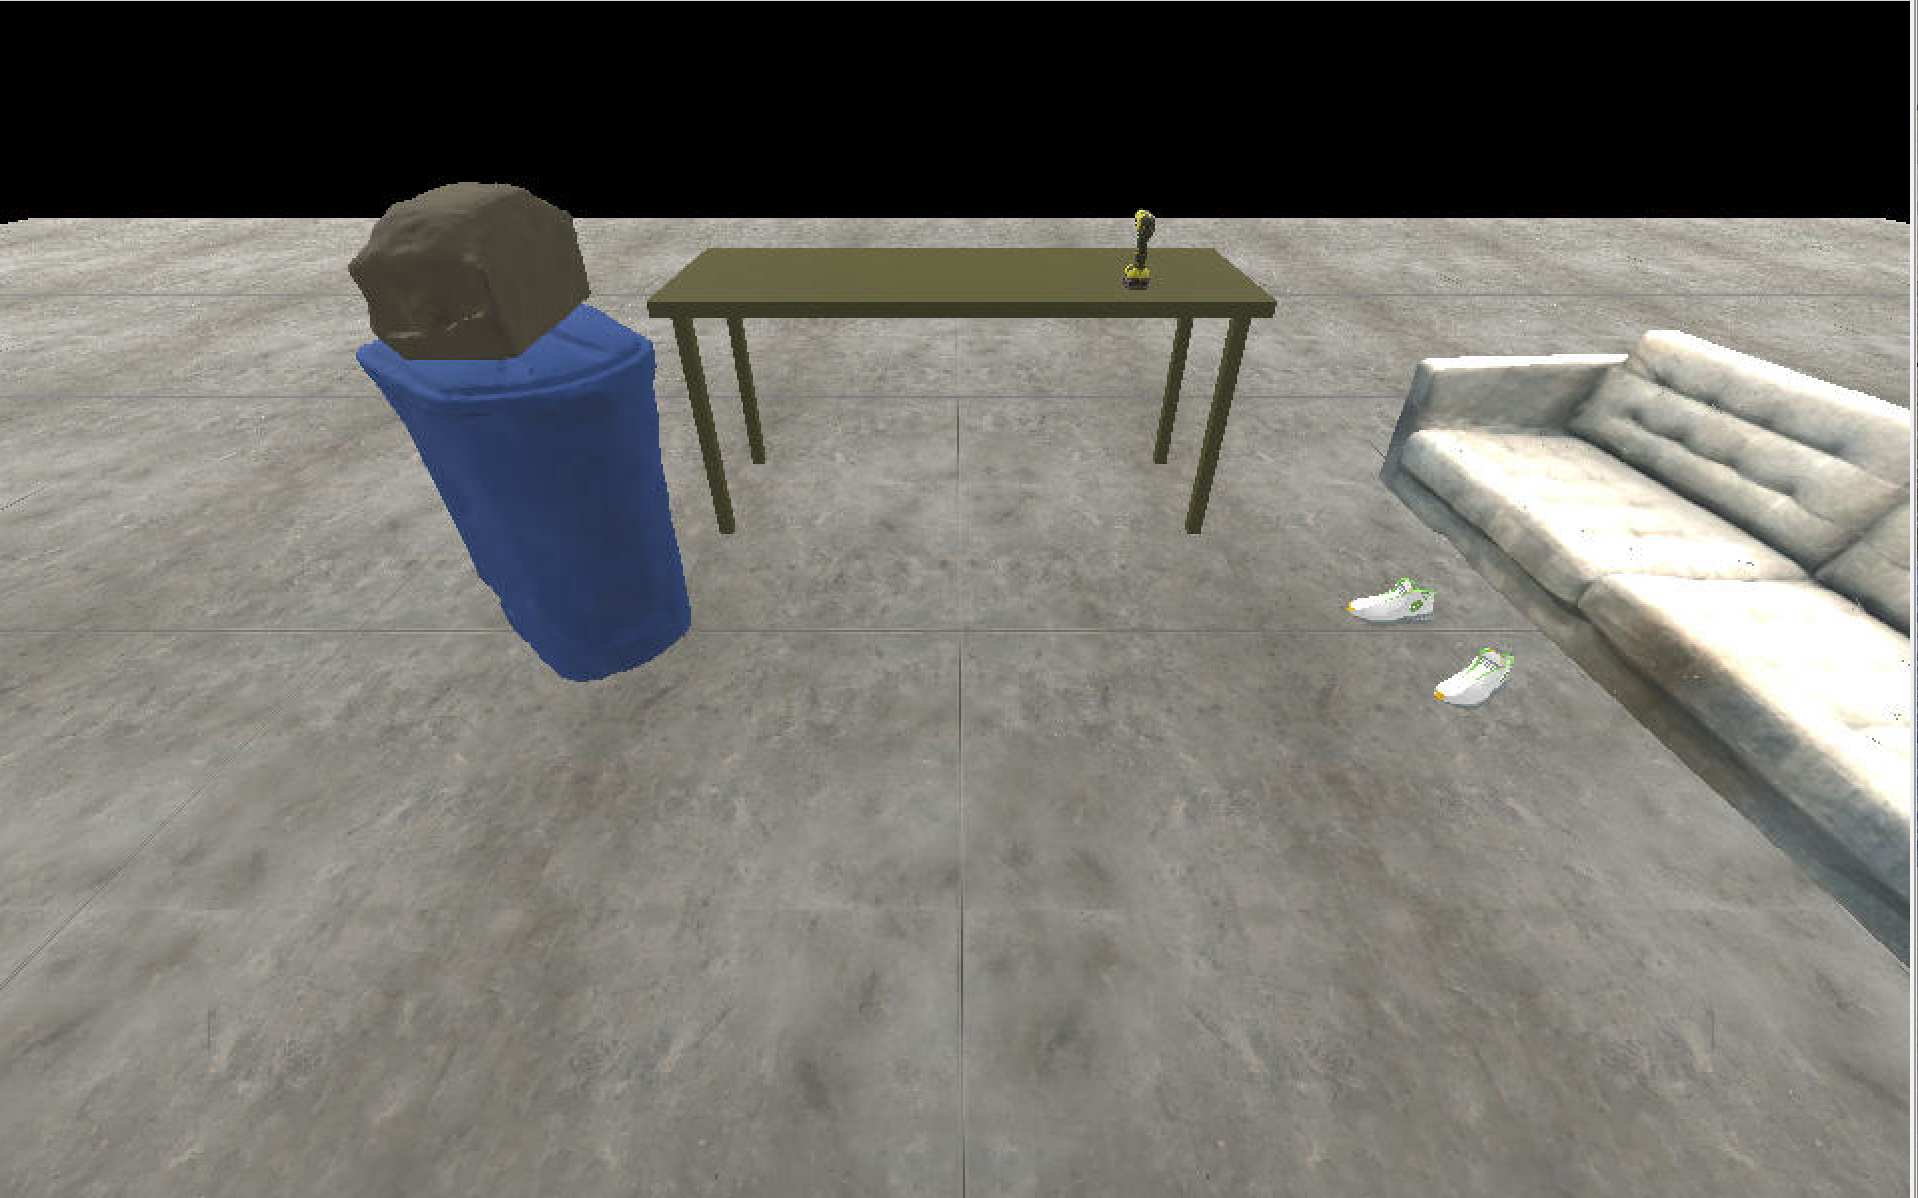

Model Response:
Based on the image provided, here are the objects that can be seen:

- **A blue trash can:** Located on the left side of the image. It has a brown, lumpy object (possibly a bag or a piece of debris) on top of it.
- **A rectangular table:** Positioned in the center of the scene. It has a dark green or brown top and matching legs. A small yellow and black object, resembling a power drill, is sitting on the table.
- **A gray couch:** Located on the right side of the image. It appears to be a sectional sofa with tufted cushions.
- **A pair of white sneakers:** These are on the floor, near the couch. They have green accents on the laces and sole.
- **The floor:** The entire floor is made of large, gray concrete tiles with visible seams.
- **The background:** The top of the image is a solid black bar, which may indicate this is a screenshot from a video game or a 3D modeling software.

The overall scene appears to be a simple, sparse room, possibly a digital rendering or a ga

In [4]:
from PIL import Image
from IPython.display import display

# Load local image
local_image_path = "room_expo.png"
image = Image.open(local_image_path)

# Display the image
display(image)


# Prepare messages with local image
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What objects can you see in this image?"},
        ],
    }
]

# Process and generate
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("Model Response:")
print(output_text[0])

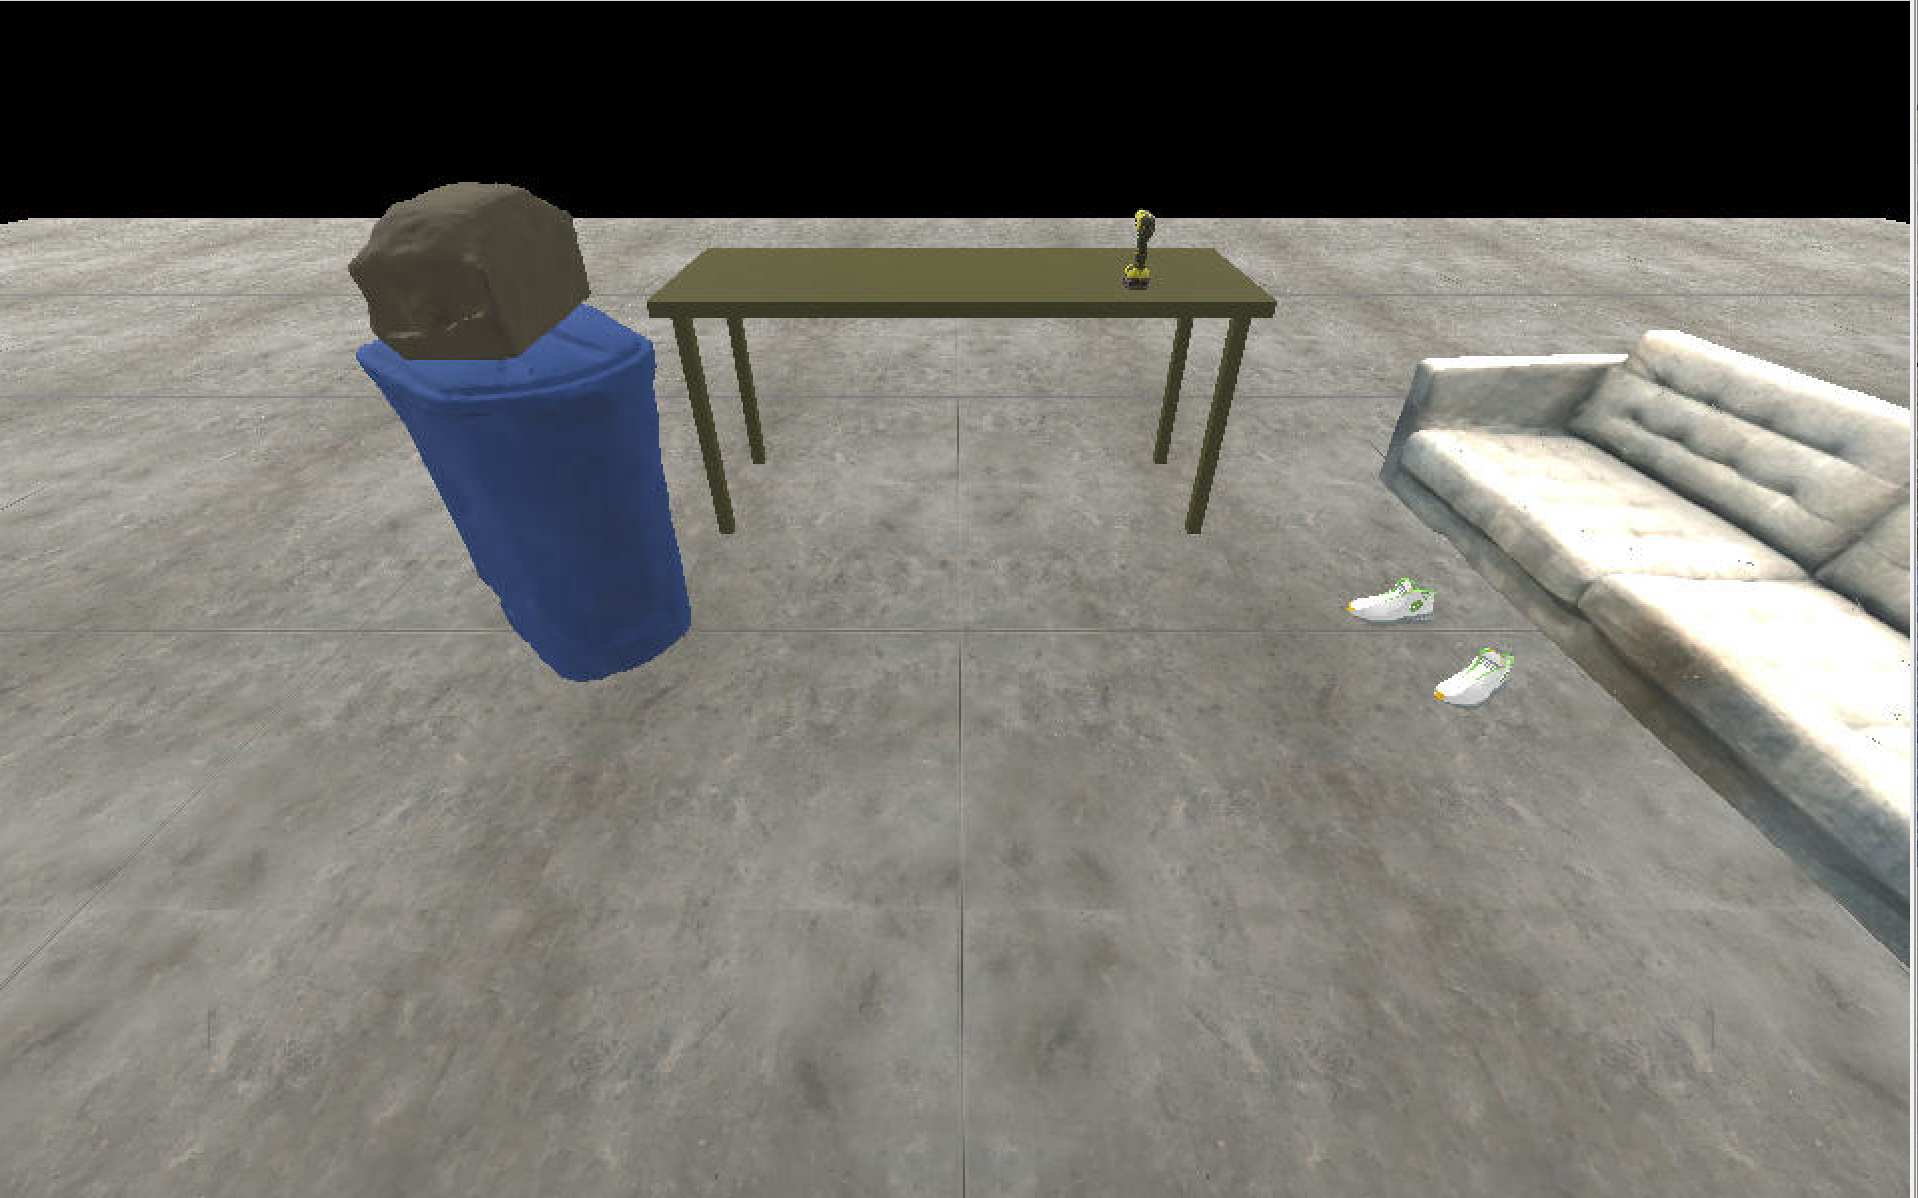

Model Response:
```json
[
    {"bbox_2d": [181, 151, 362, 570], "label": "bin"},
    {"bbox_2d": [336, 204, 666, 448], "label": "table"},
    {"bbox_2d": [717, 273, 998, 808], "label": "couch"},
    {"bbox_2d": [583, 174, 603, 240], "label": "drill"},
    {"bbox_2d": [700, 483, 747, 520], "label": "shoes"},
    {"bbox_2d": [744, 542, 790, 591], "label": "shoes"}
]
```


In [10]:
from PIL import Image
from IPython.display import display

# Load local image
local_image_path = "room_expo.png"
image = Image.open(local_image_path)

# Display the image
display(image)


# Prepare messages with local image
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Create a json oupt for each  object in the image in the format {'bbox_2d': [181, 151, 362, 570], 'label': 'bin'}, If there are multiple objects with same label insert numericals 'bin1', 'bin2',.. "},
        ],
    }
]

# Process and generate
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("Model Response:")
print(output_text[0])

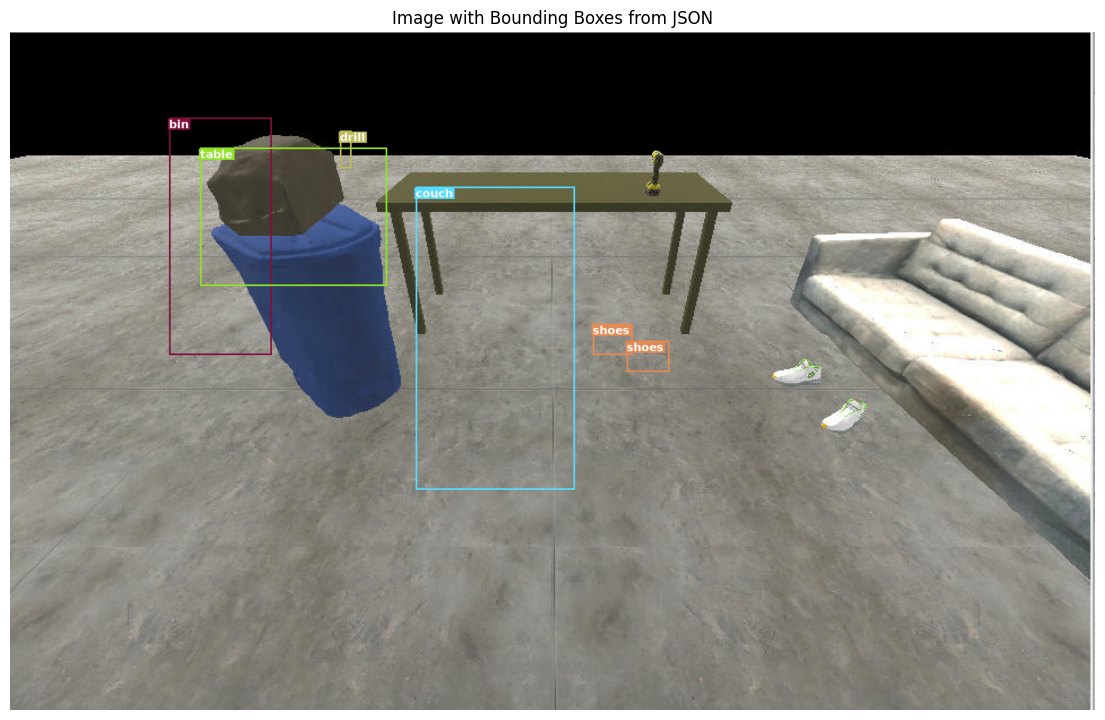

Saved to 'image_with_bboxes.png'


In [14]:
import json
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import random

# Load image
image_path = "room_expo.png"
image = Image.open(image_path)

# Bounding boxes data
bboxes_json = [
    {"bbox_2d": [181+100, 151, 362+100, 570], "label": "bin"},
    {"bbox_2d": [336, 204, 666, 448], "label": "table"},
    {"bbox_2d": [717, 273, 998, 808], "label": "couch"},
    {"bbox_2d": [583, 174, 603, 240], "label": "drill"},
    {"bbox_2d": [1030, 515, 1100, 570], "label": "shoes"},
    {"bbox_2d": [1090, 545, 1165, 600], "label": "shoes"}
]

# Create a copy to draw on
image_with_boxes = image.copy()
draw = ImageDraw.Draw(image_with_boxes)

# Try to load a font, fallback to default if not available
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
except:
    font = ImageFont.load_default()

# Generate random colors for each unique label
unique_labels = list(set([item["label"] for item in bboxes_json]))
colors = {}
for label in unique_labels:
    colors[label] = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

# Draw bounding boxes
for item in bboxes_json:
    bbox = item["bbox_2d"]
    label = item["label"]
    x1, y1, x2, y2 = bbox

    color = colors[label]

    # Draw rectangle
    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

    # Draw label background
    text = label
    bbox_text = draw.textbbox((x1, y1), text, font=font)
    draw.rectangle([bbox_text[0]-2, bbox_text[1]-2, bbox_text[2]+2, bbox_text[3]+2], fill=color)

    # Draw label text
    draw.text((x1, y1), text, fill="white", font=font)

# Display result
plt.figure(figsize=(14, 10))
plt.imshow(image_with_boxes)
plt.axis('off')
plt.title('Image with Bounding Boxes from JSON')
plt.show()

# Save result
image_with_boxes.save('image_with_bboxes.png')
print("Saved to 'image_with_bboxes.png'")